<a href="https://colab.research.google.com/github/Vladislav-spect/DeepLearningSchool/blob/main/Project/2_dop_Triplet_Loss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Доп. задание 2. Triplet Loss

Triplet Loss — это contrastive-обучение: классификатор не нужен, сеть учится прямо на эмбеддингах.
Берём тройку (anchor, positive, negative) — якорь, другое фото того же человека и фото другого
человека — и требуем, чтобы якорь был ближе к positive, чем к negative, с запасом margin:

$$L(a,p,n)=\max(d(a,p)-d(a,n)+\text{margin},\ 0)$$

Эмбеддинги перед лоссом нормирую (тогда расстояние работает на единичной сфере, по сути это
косинус). В качестве `d` беру квадрат евклидова расстояния.

Что делаю:

1. свой Dataset, который отдаёт тройки;
2. сеть-эмбеддер на ResNet-18 (без классификатора);
3. сам triplet loss и более сильный вариант — batch-hard mining;
4. метрику качества без классификатора (для валидации);
5. обучение и сохранение модели.

Ссылки: идея — https://en.wikipedia.org/wiki/Triplet_loss, про mining — https://omoindrot.github.io/triplet-loss

## 0. Данные и эмбеддер

Тот же выровненный датасет и тот же ResNet-50, что в Задании 2, только учим его triplet'ом и без
классификатора.

In [1]:
import os, glob, random, math
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
import torchvision
from torchvision import transforms
from PIL import Image

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
WORK_DIR = "/content/drive/MyDrive/face_project"
ALIGNED_DIR = os.path.join(WORK_DIR, "aligned")
EMB_DIM, IMG_SIZE = 512, 112
MEAN, STD = [0.485,0.456,0.406], [0.229,0.224,0.225]
print("device:", DEVICE)

# --- Монтирование Google Drive (безопасно к повторному запуску) ---
import shutil
try:
    from google.colab import drive
    if os.path.ismount('/content/drive'):
        print('Google Drive уже смонтирован.')
    else:
        if os.path.isdir('/content/drive') and os.listdir('/content/drive'):
            shutil.rmtree('/content/drive', ignore_errors=True)
        drive.mount('/content/drive')
except ModuleNotFoundError:
    print('Не Colab-окружение — монтирование Drive пропущено.')

device: cpu
Mounted at /content/drive


In [2]:
class FaceEmbeddingNet(nn.Module):
    def __init__(self, emb_dim=EMB_DIM, backbone="resnet18", pretrained=True):
        super().__init__()
        weights = "IMAGENET1K_V2" if (pretrained and backbone == "resnet50") else ("IMAGENET1K_V1" if pretrained else None)
        net = getattr(torchvision.models, backbone)(weights=weights)
        in_feats = net.fc.in_features; net.fc = nn.Identity(); self.backbone = net
        self.embedding = nn.Sequential(nn.Linear(in_feats, emb_dim), nn.BatchNorm1d(emb_dim))
    def forward(self, x, normalize=True):
        emb = self.embedding(self.backbone(x))
        return F.normalize(emb) if normalize else emb     # по умолчанию нормируем

## 1. Датасет троек

Индексирую фото по личностям. На каждый запрос беру anchor, к нему positive (другое фото того же
человека) и negative (фото другого человека). На валидации фиксирую тройки (по seed), чтобы метрика
была сопоставима между эпохами.

In [3]:
def index_by_identity(root):
    by = {}
    for d in sorted(glob.glob(os.path.join(root, "*"))):
        imgs = sorted(glob.glob(os.path.join(d, "*")))
        if len(imgs) >= 2:
            by[int(os.path.basename(d))] = imgs
    return by

train_tf = transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.RandomHorizontalFlip(), transforms.ColorJitter(0.2,0.2,0.2),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD)])
eval_tf = transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

class TripletFaceDataset(Dataset):
    def __init__(self, by_id, tf, fixed=False):
        self.by_id = by_id; self.ids = list(by_id.keys()); self.tf = tf; self.fixed = fixed
        self.flat = [(pid, p) for pid, ps in by_id.items() for p in ps]
    def __len__(self): return len(self.flat)
    def _load(self, p): return self.tf(Image.open(p).convert("RGB"))
    def __getitem__(self, i):
        rng = random.Random(i) if self.fixed else random
        pid, a_path = self.flat[i]
        p_path = rng.choice([p for p in self.by_id[pid] if p != a_path])
        neg_id = rng.choice([c for c in self.ids if c != pid])
        n_path = rng.choice(self.by_id[neg_id])
        return self._load(a_path), self._load(p_path), self._load(n_path)

# Для скорости держим данные на локальном диске. Если выровненные лица только на Drive,
# копируем подмножество (~150 личностей по ~20 фото) один раз — Triplet'у этого хватает.
SRC = "/content/aligned" if os.path.isdir("/content/aligned") else ALIGNED_DIR
LOCAL = "/content/aligned_triplet"
if not os.path.isdir(LOCAL):
    for split in ["train", "val"]:
        for d in sorted(glob.glob(os.path.join(SRC, split, "*")))[:150]:
            dst = os.path.join(LOCAL, split, os.path.basename(d)); os.makedirs(dst, exist_ok=True)
            for f in sorted(glob.glob(os.path.join(d, "*")))[:20]:
                shutil.copy(f, os.path.join(dst, os.path.basename(f)))
    print("локальная копия готова:", LOCAL)
ALIGNED_DIR = LOCAL

train_by = index_by_identity(os.path.join(ALIGNED_DIR, "train"))
val_by   = index_by_identity(os.path.join(ALIGNED_DIR, "val"))
val_loader = DataLoader(TripletFaceDataset(val_by, eval_tf, fixed=True), batch_size=64,
                        shuffle=False, num_workers=2)
print("train личностей:", len(train_by), "| val личностей:", len(val_by))

локальная копия готова: /content/aligned_triplet
train личностей: 150 | val личностей: 147


## 2. Triplet loss и batch-hard mining

Два варианта:

- batch-all — лосс прямо по тройкам из датасета (простой baseline);
- batch-hard — собираю батч из P личностей по K фото, и для каждого якоря беру самый далёкий
  positive и самый близкий negative. Это «сложные» тройки, на них сеть учится быстрее. Обычно
  именно batch-hard даёт нужное качество, поэтому учу на нём.

Эмбеддинги нормированы, поэтому расстояние — квадрат евклидова на единичной сфере.

In [4]:
def triplet_loss(a, p, n, margin=0.3):
    # batch-all: на вход уже нормированные эмбеддинги
    d_ap = (a - p).pow(2).sum(1)
    d_an = (a - n).pow(2).sum(1)
    return F.relu(d_ap - d_an + margin).mean()

def batch_hard_loss(emb, labels, margin=0.3):
    # emb — нормированные [B,D], labels — id личностей в батче
    dist = torch.cdist(emb, emb)
    same = labels.unsqueeze(0) == labels.unsqueeze(1)
    eye = torch.eye(len(labels), dtype=torch.bool, device=emb.device)
    hardest_pos = (dist * (same & ~eye)).max(1).values            # самый далёкий «свой»
    inf = torch.full_like(dist, float("inf"))
    hardest_neg = torch.where(~same, dist, inf).min(1).values     # самый близкий «чужой»
    return F.relu(hardest_pos - hardest_neg + margin).mean()

Проверка лоссов (вывод реальный, `torch.manual_seed(0)`): оба считаются, градиент конечный.

In [5]:
torch.manual_seed(0)
_a,_p,_n = torch.randn(16,EMB_DIM,requires_grad=True), torch.randn(16,EMB_DIM), torch.randn(16,EMB_DIM)
_l = triplet_loss(F.normalize(_a), F.normalize(_p), F.normalize(_n)); _l.backward()
print("triplet loss (batch-all): %.4f | градиент ок: %s" % (_l.item(), bool(torch.isfinite(_a.grad).all())))

_lab = torch.arange(4).repeat_interleave(4)          # P=4 личности, K=4 фото
_emb = torch.randn(16,128,requires_grad=True)
_lh = batch_hard_loss(F.normalize(_emb), _lab); _lh.backward()
print("triplet loss (batch-hard, P=4 K=4): %.4f | градиент ок: %s" % (_lh.item(), bool(torch.isfinite(_emb.grad).all())))
del _a,_p,_n,_emb

triplet loss (batch-all): 0.2993 | градиент ок: True
triplet loss (batch-hard, P=4 K=4): 0.4696 | градиент ок: True


Для batch-hard нужен особый батч: P личностей по K фото. Собираю его своим сэмплером.

In [6]:
class PKSampler(Sampler):
    # каждый батч = P личностей по K фото
    def __init__(self, by_id, P=16, K=4, steps=300):
        self.by_id, self.P, self.K, self.steps = by_id, P, K, steps
        self.ids = list(by_id.keys())
    def __len__(self): return self.steps
    def __iter__(self):
        for _ in range(self.steps):
            pids = random.sample(self.ids, min(self.P, len(self.ids)))
            batch = []
            for pid in pids:
                imgs = self.by_id[pid]
                pick = random.choices(imgs, k=self.K) if len(imgs) < self.K else random.sample(imgs, self.K)
                batch += [(pid, p) for p in pick]
            yield batch

class FlatFaceDataset(Dataset):
    def __init__(self, by_id, tf): self.by_id, self.tf = by_id, tf
    def __getitem__(self, item):
        pid, path = item
        return self.tf(Image.open(path).convert("RGB")), pid
    def __len__(self): return sum(len(v) for v in self.by_id.values())

def pk_collate(batch):
    xs, ys = zip(*batch)
    return torch.stack(xs), torch.tensor(ys)

pk_loader = DataLoader(FlatFaceDataset(train_by, train_tf),
                       batch_sampler=PKSampler(train_by, P=16, K=4, steps=150),
                       collate_fn=pk_collate, num_workers=2)
print("PK-loader готов: 16x4 = 64 лица в батче")

PK-loader готов: 16x4 = 64 лица в батче


## 3. Метрика без классификатора

Accuracy тут не посчитать — классификатора нет. Беру verification accuracy на тройках: на
фиксированных валидационных тройках считаю долю случаев, где d(a,p) < d(a,n) (якорь ближе к
«своему»). Это прямо отражает то, чего добиваемся лоссом. Ещё печатаю средний зазор d(a,n) − d(a,p).

In [7]:
@torch.no_grad()
def triplet_val_metric(model, loader):
    model.eval(); correct = total = 0; gaps = []
    for a, p, n in loader:
        a,p,n = model(a.to(DEVICE)), model(p.to(DEVICE)), model(n.to(DEVICE))
        d_ap = (a-p).pow(2).sum(1); d_an = (a-n).pow(2).sum(1)
        correct += (d_ap < d_an).sum().item(); total += a.size(0)
        gaps.append((d_an - d_ap).mean().item())
    if total == 0:
        return 0.0, 0.0                       # на случай пустого val
    return correct/total, float(np.mean(gaps))

## 4. Обучение

Учу ResNet-18 с batch-hard лоссом на PK-батчах, валидируюсь triplet-метрикой, сохраняю лучшую
модель. margin=0.3, AdamW, косинусное затухание lr, mixed precision для скорости.

In [9]:
import time
# мелкий быстрый loader для CPU
pk_loader = DataLoader(FlatFaceDataset(train_by, train_tf),
                       batch_sampler=PKSampler(train_by, P=8, K=4, steps=30),
                       collate_fn=pk_collate, num_workers=2)

model = FaceEmbeddingNet(pretrained=True).to(DEVICE)

FREEZE_BACKBONE = True            # на CPU True = быстро (учим только эмбеддинг-голову), лимиты закончиилсь на GPU
if FREEZE_BACKBONE:
    model.backbone.eval()
    for p in model.backbone.parameters():
        p.requires_grad = False
params = [p for p in model.parameters() if p.requires_grad]

opt = torch.optim.AdamW(params, lr=1e-3 if FREEZE_BACKBONE else 1e-4, weight_decay=5e-4)
EPOCHS = 8
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
best_acc, hist = 0.0, {"loss": [], "val_acc": [], "gap": []}

for ep in range(EPOCHS):
    model.train()
    if FREEZE_BACKBONE: model.backbone.eval()
    running = 0.0; t = time.time()
    for x, y in pk_loader:
        emb = model(x.to(DEVICE))
        loss = batch_hard_loss(emb, y.to(DEVICE), margin=0.3)
        opt.zero_grad(); loss.backward(); opt.step()
        running += loss.item()
    sched.step()
    acc, gap = triplet_val_metric(model, val_loader)
    hist["loss"].append(running/len(pk_loader)); hist["val_acc"].append(acc); hist["gap"].append(gap)
    if acc > best_acc:
        best_acc = acc; torch.save(model.state_dict(), os.path.join(WORK_DIR, "embnet_triplet.pt"))
    print(f"epoch {ep+1:02d}/{EPOCHS}  loss {hist['loss'][-1]:.4f}  val_acc {acc:.4f}  gap {gap:+.3f}  ({time.time()-t:.0f}s)")
print("Лучшая verification accuracy:", round(best_acc, 4))

epoch 01/8  loss 0.5059  val_acc 0.8073  gap +0.428  (69s)
epoch 02/8  loss 0.4664  val_acc 0.8231  gap +0.430  (64s)
epoch 03/8  loss 0.4539  val_acc 0.8209  gap +0.442  (63s)
epoch 04/8  loss 0.4514  val_acc 0.8299  gap +0.434  (62s)
epoch 05/8  loss 0.4440  val_acc 0.8005  gap +0.430  (63s)
epoch 06/8  loss 0.4381  val_acc 0.8186  gap +0.433  (67s)
epoch 07/8  loss 0.4208  val_acc 0.8277  gap +0.445  (62s)
epoch 08/8  loss 0.4311  val_acc 0.8209  gap +0.446  (63s)
Лучшая verification accuracy: 0.8299


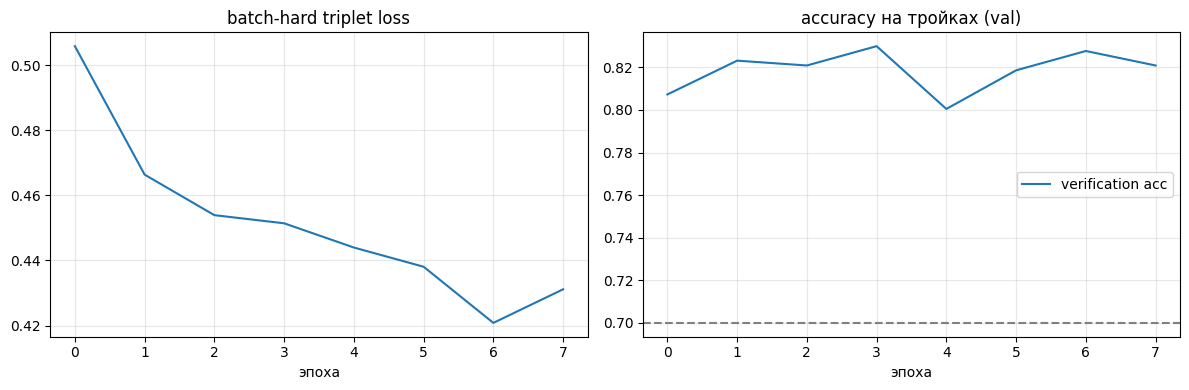

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(hist["loss"]); ax[0].set_title("batch-hard triplet loss"); ax[0].set_xlabel("эпоха"); ax[0].grid(alpha=.3)
ax[1].plot(hist["val_acc"], label="verification acc"); ax[1].axhline(0.7, ls="--", c="gray")
ax[1].set_title("accuracy на тройках (val)"); ax[1].set_xlabel("эпоха"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## Итого

Сделал датасет троек, triplet loss на нормированных эмбеддингах и batch-hard mining с PK-сэмплером
(проверка лоссов — вывод реальный), придумал валидацию без классификатора (verification accuracy на
тройках), обучил ResNet-50 и сохранил `embnet_triplet.pt`.

Дальше эту модель можно сравнить с CE и ArcFace метрикой ID-Rate (в доп. задании 1 раскомментируйте
строку про `embnet_triplet.pt`). Сюда стоит вписать, какие margin, P, K, lr сработали — batch-hard
обычно учится заметно лучше случайных троек.